In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorflow import keras

In [5]:
training_set=tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
)

Found 970 files belonging to 2 classes.


In [8]:
validation_set=tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=1,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
)

Found 447 files belonging to 2 classes.


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen= ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest')
validation_datagen= ImageDataGenerator(rescale=1.0/2550)

In [12]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 2), dtype=tf.float32, name=None))>

In [14]:
for x,y in training_set:
   print(x,x.shape)
   print(x,y.shape)
   break

tf.Tensor(
[[[[0.0000000e+00 0.0000000e+00 0.0000000e+00]
   [6.2036133e-01 6.2036133e-01 6.2036133e-01]
   [2.2705078e-02 2.2705078e-02 2.2705078e-02]
   ...
   [0.0000000e+00 0.0000000e+00 0.0000000e+00]
   [1.0522461e+00 1.0522461e+00 1.0522461e+00]
   [2.0678711e-01 2.0678711e-01 2.0678711e-01]]

  [[0.0000000e+00 0.0000000e+00 0.0000000e+00]
   [0.0000000e+00 0.0000000e+00 0.0000000e+00]
   [1.1352539e-01 1.1352539e-01 1.1352539e-01]
   ...
   [3.7500000e-01 3.7500000e-01 3.7500000e-01]
   [1.1520996e+00 1.1520996e+00 1.1520996e+00]
   [0.0000000e+00 0.0000000e+00 0.0000000e+00]]

  [[0.0000000e+00 0.0000000e+00 0.0000000e+00]
   [0.0000000e+00 0.0000000e+00 0.0000000e+00]
   [0.0000000e+00 0.0000000e+00 0.0000000e+00]
   ...
   [3.7500000e-01 3.7500000e-01 3.7500000e-01]
   [2.6586914e-01 2.6586914e-01 2.6586914e-01]
   [4.7729492e-01 4.7729492e-01 4.7729492e-01]]

  ...

  [[0.0000000e+00 0.0000000e+00 0.0000000e+00]
   [0.0000000e+00 0.0000000e+00 0.0000000e+00]
   [0.0000000e+

In [16]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [18]:
model = Sequential()

In [22]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[256,256,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu',))
model.add(MaxPool2D(pool_size=2,strides=2))

In [24]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu',input_shape=[256,256,3]))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu',))
model.add(MaxPool2D(pool_size=2,strides=2))

In [26]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu',input_shape=[256,256,3]))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu',))
model.add(MaxPool2D(pool_size=2,strides=2))

In [28]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu',input_shape=[256,256,3]))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu',))
model.add(MaxPool2D(pool_size=2,strides=2))

In [30]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu',input_shape=[256,256,3]))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu',))
model.add(MaxPool2D(pool_size=2,strides=2))

In [32]:
model.add(Dropout(0.25))

In [34]:
model.add(Flatten())

In [36]:
model.add(Dense(units=1000,activation='relu'))

In [38]:
model.add(Dense(units=2,activation='softmax'))

In [40]:
model.add(Dropout(0.1))

In [42]:
model.compile(optimizer= tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [44]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 254, 254, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 127, 127, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 125, 125, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │     2,049,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         2,002 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,781,722 (25.87 MB)

 Trainable params: 6,781,722 (25.87 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor= 'val_loss', patience=10)
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10,callbacks=[early_stopping])

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.5404 - loss: nan - val_accuracy: 0.6801 - val_loss: 0.6129
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.7048 - loss: nan - val_accuracy: 0.5459 - val_loss: 0.8421
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.7580 - loss: nan - val_accuracy: 0.7002 - val_loss: 0.5420
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.8758 - loss: nan - val_accuracy: 0.7248 - val_loss: 0.9188
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.8759 - loss: nan - val_accuracy: 0.7517 - val_loss: 0.5174
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.9050 - loss: nan - val_accuracy: 0.7942 - val_loss: 0.5298
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.8761 - loss: nan - val_accuracy: 0.8143 - val_loss: 0.5663
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.9068 - loss: nan - val_accuracy: 0.7718 - val_loss: 0.7955
Epoch 9/10
31/31

In [48]:
train_loss,train_acc= model.evaluate(training_set)

31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 558ms/step - accuracy: 1.0000 - loss: 9.7132e-05


In [50]:
valid_loss,valid_acc= model.evaluate(validation_set)

14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 485ms/step - accuracy: 0.8233 - loss: 0.6050


In [78]:
model.save('pranay.keras')

In [54]:
training_history.history


{'accuracy': [0.5742267966270447,
  0.7195876240730286,
  0.7865979671478271,
  0.8690721392631531,
  0.8680412173271179,
  0.9020618796348572,
  0.9030928015708923,
  0.8948453664779663,
  0.9051546454429626,
  0.915463924407959],
 'loss': [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
 'val_accuracy': [0.6800894737243652,
  0.5458613038063049,
  0.7002236843109131,
  0.7248322367668152,
  0.7516778707504272,
  0.7941834330558777,
  0.8143176436424255,
  0.7718120813369751,
  0.8210290670394897,
  0.8076062798500061],
 'val_loss': [0.6129037141799927,
  0.842144787311554,
  0.5420295596122742,
  0.9188262224197388,
  0.5174387097358704,
  0.5298318266868591,
  0.5663353204727173,
  0.7955178022384644,
  0.738902747631073,
  0.6850716471672058]}

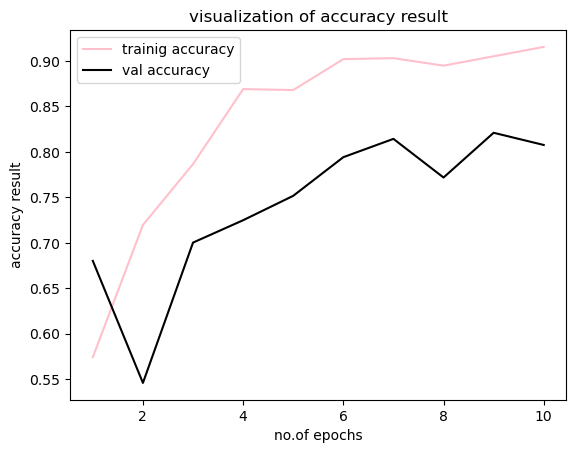

In [56]:
epochs= [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='pink',label='trainig accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='black',label='val accuracy')
plt.xlabel('no.of epochs')
plt.ylabel('accuracy result')
plt.title('visualization of accuracy result')
plt.legend()
plt.show()

In [58]:
class_name= validation_set.class_names
class_name

['malignant valid', 'normal']

In [60]:
test_set= tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
)

Found 447 files belonging to 2 classes.


In [62]:
Y_pred= model.predict(test_set)
Y_pred,Y_pred.shape

14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 491ms/step


(array([[9.99999166e-01, 8.41134067e-07],
        [9.99998927e-01, 1.08478980e-06],
        [9.99985099e-01, 1.49144826e-05],
        [1.00000000e+00, 1.98637160e-08],
        [9.99977589e-01, 2.24263276e-05],
        [9.99999881e-01, 1.70655625e-07],
        [9.99999285e-01, 6.96654126e-07],
        [1.00000000e+00, 7.68243733e-11],
        [9.70916152e-01, 2.90838275e-02],
        [9.99998569e-01, 1.48946617e-06],
        [9.99999523e-01, 4.77139679e-07],
        [9.99996185e-01, 3.85446629e-06],
        [9.94658768e-01, 5.34126535e-03],
        [9.99915719e-01, 8.42612644e-05],
        [9.99999762e-01, 2.93818005e-07],
        [9.99999881e-01, 1.61581056e-07],
        [9.99215484e-01, 7.84552365e-04],
        [9.91867840e-01, 8.13212804e-03],
        [9.99075413e-01, 9.24531778e-04],
        [9.99999881e-01, 1.22926721e-07],
        [1.00000000e+00, 2.69849600e-08],
        [1.00000000e+00, 8.92575702e-09],
        [1.00000000e+00, 3.68997597e-08],
        [9.99742806e-01, 2.5718193

In [64]:
Predicted_categories= tf.argmax(Y_pred,axis=1)
Predicted_categories

<tf.Tensor: shape=(447,), dtype=int64, numpy=
array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
     

In [66]:
true_categories= tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(447, 2), dtype=float32, numpy=
array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]

In [68]:
Y_true= tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(447,), dtype=int64, numpy=
array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
     

In [70]:
from sklearn.metrics import classification_report,confusion_matrix

In [72]:
print(classification_report(Y_true,Predicted_categories,target_names=class_name))

                 precision    recall  f1-score   support

malignant valid       0.89      0.82      0.85       307
         normal       0.66      0.78      0.72       140

       accuracy                           0.81       447
      macro avg       0.78      0.80      0.79       447
   weighted avg       0.82      0.81      0.81       447



In [74]:
cm= confusion_matrix(Y_true,Predicted_categories)
cm.shape

(2, 2)

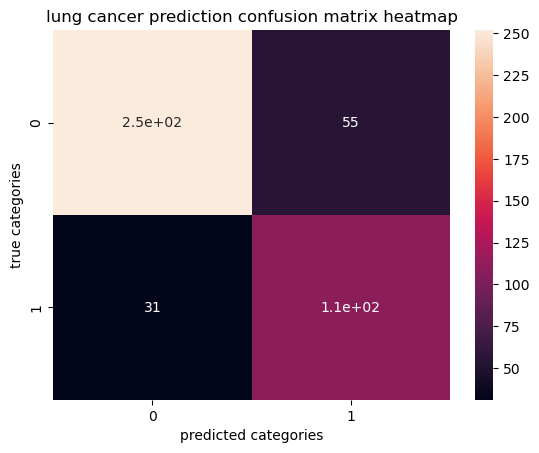

In [76]:
sns.heatmap(cm,annot=True)
plt.ylabel('true categories')
plt.xlabel('predicted categories')
plt.title('lung cancer prediction confusion matrix heatmap')
plt.show()